# Chapter 10 — The QR algorithm

**Numerical Linear Algebra: Theory, Algorithms, and Computation**

**Abdallah Alsammani, Ph.D.**  
Department of Mathematical Sciences & Data Science  
Delaware State University

Lecture notes: <https://aalsammani.github.io/numerical-linear-algebra/>  
Notes for this chapter: <https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html>  
Repository: <https://github.com/aalsammani/Numerical-Linear-Algebra-Notebooks>

This notebook is the computational laboratory of the chapter; the theory,
proofs and exercises are in the lecture notes, to which the links below
point. References such as Trefethen and Bau (1997) are listed in the
[bibliography of the notes](https://aalsammani.github.io/numerical-linear-algebra/back/bibliography.html). Version
1.0, September 2026.

---

This notebook accompanies [Chapter 10](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10) of the notes. We build
the practical QR algorithm from its parts, check every part against NumPy and
SciPy, and measure how it behaves.

**Learning objectives.** After working through this lab you should be able to

1. reduce a matrix to Hessenberg or tridiagonal form with Householder
   reflectors and verify the result against `scipy.linalg.hessenberg`;
2. verify numerically that the unshifted QR algorithm computes the QR
   factorization of $A^k$, and measure its linear convergence rates;
3. implement a QR step on a Hessenberg matrix with Givens rotations, and the
   symmetric tridiagonal QR algorithm with the Wilkinson shift and deflation;
4. demonstrate the failure of the Rayleigh quotient shift and of a single real
   shift for complex eigenvalues, and implement the Francis double-shift step;
5. count QR steps per eigenvalue and interpret the counts as observations;
6. explain why singular values should not be computed from $A^TA$, and
   implement Golub--Kahan bidiagonalization.

Run the cells in order from a fresh kernel.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import scipy
import scipy.linalg as sla
from scipy.optimize import linear_sum_assignment

rng = np.random.default_rng(20261010)
u = np.finfo(float).eps / 2          # unit roundoff of IEEE double precision, 2**-53
plt.rcParams.update({"figure.figsize": (6.4, 4.0), "axes.grid": True, "grid.alpha": 0.3})
print(f"NumPy {np.__version__}, SciPy {scipy.__version__}; unit roundoff u = {u:.3e}")

NumPy 2.5.3, SciPy 1.18.1; unit roundoff u = 1.110e-16


## 1. Householder reduction to Hessenberg form

The reflector of step $k$ acts on rows and columns $k+1,\dots,n$
([Algorithm 10.1](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10-alg-hessenberg)). We use the Householder vector of
[Algorithm 1.1](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#ch01-alg-householder), normalized so that $v_1 = 1$, and never form
a reflector as a matrix.

In [2]:
def house(x):
    """Return v (v[0] = 1) and beta with (I - beta v v^T) x = alpha e_1, |alpha| = ||x||."""
    x = np.asarray(x, dtype=float)
    normx = np.linalg.norm(x)
    v = x.copy()
    if normx == 0.0:
        v[:] = 0.0
        v[0] = 1.0
        return v, 0.0
    v[0] = x[0] + (1.0 if x[0] >= 0 else -1.0) * normx   # no cancellation
    v /= v[0]
    return v, 2.0 / (v @ v)


def hessenberg_householder(A, calc_q=True):
    """Householder reduction A = Q H Q^T with H upper Hessenberg."""
    H = np.array(A, dtype=float)
    n = H.shape[0]
    Q = np.eye(n)
    for k in range(n - 2):
        v, beta = house(H[k + 1:, k])
        H[k + 1:, k:] -= beta * np.outer(v, v @ H[k + 1:, k:])     # from the left: rows k+1..n
        H[:, k + 1:] -= beta * np.outer(H[:, k + 1:] @ v, v)       # from the right: columns k+1..n
        H[k + 2:, k] = 0.0                                         # exact zeros below the subdiagonal
        if calc_q:
            Q[:, k + 1:] -= beta * np.outer(Q[:, k + 1:] @ v, v)
    return H, Q

**Verification.** [Theorem 10.2](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10-thm-hessenberg-stability) says that the
computed $H$ is exactly orthogonally similar to $A + \delta A$ with
$\|\delta A\|/\|A\| = \mathcal{O}(u)$, with a constant that grows modestly
with $n$. We therefore test the residual $\|A - QHQ^T\|_F/\|A\|_F$ and the
orthogonality $\|Q^TQ - I\|_F$ against $10nu$. SciPy's `hessenberg` (LAPACK
`dgehrd`) uses the same reflectors up to signs, so the two Hessenberg matrices
agree entry by entry in absolute value up to rounding errors; we also compare
eigenvalues, which are what the similarity must preserve.

In [3]:
n = 100
A = rng.standard_normal((n, n))
H, Q = hessenberg_householder(A)
H_sp, Q_sp = sla.hessenberg(A, calc_q=True)

res = np.linalg.norm(A - Q @ H @ Q.T, "fro") / np.linalg.norm(A, "fro")
orth = np.linalg.norm(Q.T @ Q - np.eye(n), "fro")
below = np.abs(np.tril(H, -2)).max()
diff_sp = np.abs(np.abs(H) - np.abs(H_sp)).max() / np.linalg.norm(A, 2)
print(f"||A - Q H Q^T||_F / ||A||_F = {res:.2e}   (10 n u = {10 * n * u:.2e})")
print(f"||Q^T Q - I||_F             = {orth:.2e}")
print(f"largest entry below the subdiagonal = {below}")
print(f"max | |H| - |H_scipy| | / ||A||_2  = {diff_sp:.2e}")
assert res < 10 * n * u and orth < 10 * n * u and below == 0.0
assert diff_sp < 1e3 * n * u     # two backward stable computations of the same H (up to signs)

||A - Q H Q^T||_F / ||A||_F = 1.22e-15   (10 n u = 1.11e-13)
||Q^T Q - I||_F             = 9.30e-15
largest entry below the subdiagonal = 0.0
max | |H| - |H_scipy| | / ||A||_2  = 4.17e-14


In [4]:
# Eigenvalues are preserved: match the eigenvalues of H and A and compare.
lam_A = np.linalg.eigvals(A)
lam_H = np.linalg.eigvals(H)
rows, cols = linear_sum_assignment(np.abs(lam_A[:, None] - lam_H[None, :]))
print(f"max |lambda(A) - lambda(H)| = {np.abs(lam_A[rows] - lam_H[cols]).max():.2e}")

max |lambda(A) - lambda(H)| = 6.50e-14


The eigenvalues agree to roughly $10^{-13}$ or better. They cannot be expected to agree to
$u\|A\|$: each set is computed with a backward error of order $u\|A\|$, and
for a nonsymmetric matrix the forward error is that times the eigenvalue
condition number ([Chapter 9](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09)).

**The worked example.** We reproduce [Example 10.1](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10-exa-tridiag).

In [5]:
A3 = np.array([[1.0, 3.0, 4.0], [3.0, 2.0, 1.0], [4.0, 1.0, 3.0]])
T3, Q3 = hessenberg_householder(A3)
print(np.round(T3, 12))
assert np.allclose(T3, [[1, -5, 0], [-5, 3.6, -0.2], [0, -0.2, 1.4]], rtol=0, atol=10 * u * 8)
print("trace:", np.trace(T3), "  ||T||_F^2:", np.linalg.norm(T3, "fro") ** 2)

[[ 1.  -5.   0. ]
 [-5.   3.6 -0.2]
 [ 0.  -0.2  1.4]]
trace: 6.0   ||T||_F^2: 66.00000000000001


**Symmetric matrices.** For symmetric $A$ the result is tridiagonal. Note that
`scipy.linalg.hessenberg` does not know that its input is symmetric: it
calls the general routine `dgehrd` and returns a matrix whose entries outside
the tridiagonal band are rounding errors, not exact zeros. (It is a
Householder reduction; it does not use the Lanczos process.) LAPACK's
symmetric reduction `dsytrd`, available as `scipy.linalg.lapack.dsytrd`,
works on one triangle and returns the diagonal and off-diagonal directly.

In [6]:
S = rng.standard_normal((n, n))
S = (S + S.T) / 2
H_S = sla.hessenberg(S)
band = np.triu(np.tril(H_S, 1), -1)
print(f"scipy.linalg.hessenberg on symmetric S: largest entry outside the band = "
      f"{np.abs(H_S - band).max():.1e}")
lwork = int(sla.lapack.dsytrd_lwork(n)[0])
_, d, e, _, info = sla.lapack.dsytrd(S, lwork=lwork)
T_S = np.diag(d) + np.diag(e, 1) + np.diag(e, -1)
err = np.abs(np.linalg.eigvalsh(T_S) - np.linalg.eigvalsh(S)).max() / np.linalg.norm(S, 2)
print(f"dsytrd: info = {info}, max eigenvalue difference / ||S||_2 = {err:.1e}")
assert info == 0 and err < 10 * n * u   # both backward stable; Weyl's theorem bounds the difference

scipy.linalg.hessenberg on symmetric S: largest entry outside the band = 2.5e-15
dsytrd: info = 0, max eigenvalue difference / ||S||_2 = 2.0e-15


**Timing.** The flop counts of [Proposition 10.1](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10-prop-hessenberg-cost) are
$\tfrac{10}{3}n^3$ for `dgehrd` and $\tfrac43n^3$ for `dsytrd`, a ratio of
$2.5$. We measure the median of several runs. The run times are observations
on the machine that executed this notebook; they depend on the BLAS library,
the number of cores and the cache sizes.

In [7]:
def median_time(f, repeats=5):
    f()                                   # warm-up
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        f()
        times.append(time.perf_counter() - t0)
    return float(np.median(times))


print("   n   gehrd (s)   sytrd (s)   ratio   (flop ratio 2.5)")
for m in (250, 500, 1000):
    Sm = rng.standard_normal((m, m))
    Sm = Sm + Sm.T
    lw = int(sla.lapack.dsytrd_lwork(m)[0])
    t_ge = median_time(lambda: sla.hessenberg(Sm))
    t_sy = median_time(lambda: sla.lapack.dsytrd(Sm, lwork=lw))
    print(f"{m:5d}   {t_ge:9.4f}   {t_sy:9.4f}   {t_ge / t_sy:5.2f}")

   n   gehrd (s)   sytrd (s)   ratio   (flop ratio 2.5)
  250      0.0097      0.0077    1.26


  500      0.1095      0.0493    2.22


 1000      0.3235      0.1391    2.33


**Interpretation.** Do not expect the measured ratio to equal $2.5$. The two
routines use different blocking strategies and spend different fractions of
their time in memory-bound matrix-vector products, so their speeds in flops
per second differ; for small $n$ fixed overheads dominate, and other processes
on the machine can distort any single measurement. What the table can show is
whether the symmetric reduction is the faster one for large $n$, as the flop
counts predict; the size of its advantage, which may be well below or well
above $2.5$, is a property of this machine and its load at the time of the
run. The machine-independent statement is the flop
count; the table is a measurement on one machine. (The legacy version of this
course timed `numpy.linalg.qr` on a full and on a Hessenberg matrix; since
`numpy.linalg.qr` does not exploit Hessenberg structure, equal times were the
expected result and showed nothing about the QR algorithm.)

## 2. The unshifted QR algorithm is simultaneous iteration

[Theorem 10.3](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10-thm-powers) states that $A^k = \underline Q^{(k)}\underline
R^{(k)}$, where $\underline Q^{(k)}$ and $\underline R^{(k)}$ are the
accumulated factors. We check this for a symmetric matrix, normalizing every
QR factorization so that $R$ has a positive diagonal. Then $\underline
Q^{(k)}$ must also coincide with the matrix produced by simultaneous iteration
[(10.3)](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#equation-ch10-eq-simultaneous).

In [8]:
def qr_pos(M):
    """QR factorization with a positive diagonal in R (unique for nonsingular M)."""
    Qm, Rm = np.linalg.qr(M)
    s = np.sign(np.diag(Rm))
    s[s == 0] = 1.0
    return Qm * s, s[:, None] * Rm


n = 6
lam = np.array([6.0, 5.0, 4.0, 3.0, 2.0, 1.0])
V, _ = np.linalg.qr(rng.standard_normal((n, n)))
A = V @ np.diag(lam) @ V.T
A = (A + A.T) / 2

Ak, Qbar, Rbar = A.copy(), np.eye(n), np.eye(n)   # QR algorithm
Z = np.eye(n)                                      # simultaneous iteration
for k in range(1, 9):
    Qk, Rk = qr_pos(Ak)
    Ak = Rk @ Qk
    Qbar, Rbar = Qbar @ Qk, Rk @ Rbar
    Z, _ = qr_pos(A @ Z)
    Apow = np.linalg.matrix_power(A, k)
    err_pow = np.linalg.norm(Apow - Qbar @ Rbar) / np.linalg.norm(A, 2) ** k
    err_sim = np.linalg.norm(Z - Qbar)
    err_sim_A = np.linalg.norm(Ak - Qbar.T @ A @ Qbar) / np.linalg.norm(A, 2)
    print(f"k = {k}: ||A^k - Qbar Rbar|| / ||A||^k = {err_pow:.1e}, "
          f"||Z - Qbar|| = {err_sim:.1e}, ||A^(k) - Qbar^T A Qbar|| / ||A|| = {err_sim_A:.1e}")
    # each side is computed with O(k n u) relative rounding error; kappa(A) = 6 is modest
    assert err_pow < 100 * k * n * u and err_sim < 100 * k * n * u and err_sim_A < 100 * k * n * u

k = 1: ||A^k - Qbar Rbar|| / ||A||^k = 3.5e-16, ||Z - Qbar|| = 0.0e+00, ||A^(k) - Qbar^T A Qbar|| / ||A|| = 4.5e-16
k = 2: ||A^k - Qbar Rbar|| / ||A||^k = 4.4e-16, ||Z - Qbar|| = 8.4e-16, ||A^(k) - Qbar^T A Qbar|| / ||A|| = 4.2e-16
k = 3: ||A^k - Qbar Rbar|| / ||A||^k = 4.6e-16, ||Z - Qbar|| = 1.6e-15, ||A^(k) - Qbar^T A Qbar|| / ||A|| = 3.5e-16
k = 4: ||A^k - Qbar Rbar|| / ||A||^k = 4.0e-16, ||Z - Qbar|| = 2.9e-15, ||A^(k) - Qbar^T A Qbar|| / ||A|| = 5.1e-16
k = 5: ||A^k - Qbar Rbar|| / ||A||^k = 4.0e-16, ||Z - Qbar|| = 5.7e-15, ||A^(k) - Qbar^T A Qbar|| / ||A|| = 7.2e-16
k = 6: ||A^k - Qbar Rbar|| / ||A||^k = 3.5e-16, ||Z - Qbar|| = 8.3e-15, ||A^(k) - Qbar^T A Qbar|| / ||A|| = 8.5e-16
k = 7: ||A^k - Qbar Rbar|| / ||A||^k = 4.7e-16, ||Z - Qbar|| = 7.7e-15, ||A^(k) - Qbar^T A Qbar|| / ||A|| = 1.2e-15
k = 8: ||A^k - Qbar Rbar|| / ||A||^k = 5.8e-16, ||Z - Qbar|| = 5.2e-15, ||A^(k) - Qbar^T A Qbar|| / ||A|| = 9.4e-16


All three identities hold to within a small multiple of $u$ in these eight
steps. (For many more steps and a more ill-conditioned matrix, the
comparison with simultaneous iteration degrades: the columns of $A^k$ become
nearly parallel, and a small perturbation of $A^k$ changes its $Q$ factor a
lot. The identity is exact; its numerical verification is limited by
conditioning.)

**Two steps by hand.** [Example 10.2](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10-exa-two-by-two) and
[Exercise 10.4](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10-ex-two-by-two) give closed forms for $A = \begin{bmatrix}2&1\\1&2\end{bmatrix}$.

In [9]:
A2 = np.array([[2.0, 1.0], [1.0, 2.0]])
Ak = A2.copy()
for k in range(1, 6):
    Qk, Rk = qr_pos(Ak)
    Ak = Rk @ Qk
    exact_21, exact_11 = 2 * 3.0**k / (9.0**k + 1), 3 - 2 / (9.0**k + 1)
    print(f"k = {k}: a21 = {Ak[1, 0]: .6e} (formula {exact_21:.6e}),  a11 = {Ak[0, 0]:.12f}")
    assert abs(abs(Ak[1, 0]) - exact_21) < 10 * k * u * 3 and abs(Ak[0, 0] - exact_11) < 10 * k * u * 3

k = 1: a21 =  6.000000e-01 (formula 6.000000e-01),  a11 = 2.800000000000
k = 2: a21 =  2.195122e-01 (formula 2.195122e-01),  a11 = 2.975609756098
k = 3: a21 =  7.397260e-02 (formula 7.397260e-02),  a11 = 2.997260273973
k = 4: a21 =  2.468760e-02 (formula 2.468760e-02),  a11 = 2.999695214874
k = 5: a21 =  8.230313e-03 (formula 8.230313e-03),  a11 = 2.999966130398


### Convergence rates

We now watch the subdiagonal entries of $A^{(k)}$ for a symmetric matrix with
eigenvalues $10, 9, 6, 3, 1$, which is the experiment of
[Figure 10.2](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10-fig-unshifted-rates). By
[Theorem 10.4](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10-thm-unshifted-convergence) the entry $a^{(k)}_{j+1,j}$ should
decay like $|\lambda_{j+1}/\lambda_j|^k$. We fit the slope of
$\log|a^{(k)}_{j+1,j}|$ over the last part of each curve.

j = 1: observed rate 0.9000, predicted lambda_2/lambda_1 = 0.9000
j = 2: observed rate 0.6667, predicted lambda_3/lambda_2 = 0.6667
j = 3: observed rate 0.5000, predicted lambda_4/lambda_3 = 0.5000
j = 4: observed rate 0.3333, predicted lambda_5/lambda_4 = 0.3333


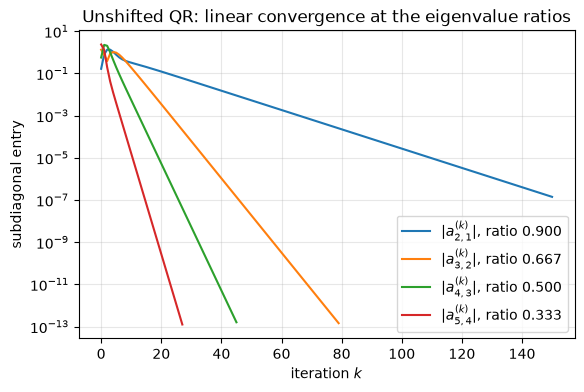

after 150 steps: max |a_jj - lambda_j| = 3.2e-14


In [10]:
lam = np.array([10.0, 9.0, 6.0, 3.0, 1.0])
n = lam.size
V, _ = np.linalg.qr(rng.standard_normal((n, n)))
A = V @ np.diag(lam) @ V.T
A = (A + A.T) / 2
kmax = 150
sub = np.zeros((kmax + 1, n - 1))
Ak = A.copy()
sub[0] = np.abs(np.diag(Ak, -1))
for k in range(1, kmax + 1):
    Qk, Rk = np.linalg.qr(Ak)
    Ak = Rk @ Qk
    sub[k] = np.abs(np.diag(Ak, -1))

fig, ax = plt.subplots()
for j in range(n - 1):
    mask = sub[:, j] > 1e-14 * np.linalg.norm(A, 2)
    ks = np.nonzero(mask)[0]
    tail = ks[len(ks) // 2:]                           # second half of the visible curve
    rate = np.exp(np.polyfit(tail, np.log(sub[tail, j]), 1)[0])
    print(f"j = {j + 1}: observed rate {rate:.4f}, predicted lambda_{j + 2}/lambda_{j + 1} = "
          f"{lam[j + 1] / lam[j]:.4f}")
    assert abs(rate - lam[j + 1] / lam[j]) < 0.02
    ax.semilogy(ks, sub[ks, j], label=rf"$|a^{{(k)}}_{{{j + 2},{j + 1}}}|$, ratio {lam[j + 1] / lam[j]:.3f}")
ax.set_xlabel("iteration $k$")
ax.set_ylabel("subdiagonal entry")
ax.set_title("Unshifted QR: linear convergence at the eigenvalue ratios")
ax.legend()
plt.show()
diag_err = np.abs(np.diag(Ak) - lam).max()
print(f"after {kmax} steps: max |a_jj - lambda_j| = {diag_err:.1e}")

The fitted rates agree with the eigenvalue ratios to several digits. The
first entry converges slowly because $9/10$ is close to one; after $150$
steps the diagonal nevertheless agrees with the eigenvalues to high accuracy,
because the diagonal entries are Rayleigh quotients and converge at the
squared rate.

**No convergence for eigenvalues of equal modulus.** The symmetric permutation
$\begin{bmatrix}0&1\\1&0\end{bmatrix}$ has eigenvalues $\pm1$ and is a fixed
point of the unshifted iteration.

In [11]:
P = np.array([[0.0, 1.0], [1.0, 0.0]])
Qp, Rp = np.linalg.qr(P)
P1 = Rp @ Qp
print(P1)
assert np.allclose(np.abs(P1), P)

[[0. 1.]
 [1. 0.]]


## 3. A QR step on a Hessenberg matrix

[Algorithm 10.2](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10-alg-hessenberg-qr-step) uses $n-1$ Givens rotations for the QR
factorization and applies their transposes on the right. We check that the
result is Hessenberg and that it agrees with the explicit step computed with
`numpy.linalg.qr`. The two QR factorizations may differ by the signs of the
columns of $Q$, $Q_{\text{np}} = QD$ with $D = \operatorname{diag}(\pm1)$,
which changes the result to $DH'D$; so we compare absolute values.

In [12]:
def givens(a, b):
    """c, s with [[c, s], [-s, c]] @ [a, b] = [r, 0], r = hypot(a, b)."""
    if b == 0.0:
        return 1.0, 0.0
    r = np.hypot(a, b)
    return a / r, b / r


def hessenberg_qr_step(H, mu=0.0):
    """One explicitly shifted QR step H - mu I = QR, H <- RQ + mu I, with Givens rotations."""
    H = np.array(H, dtype=float)
    n = H.shape[0]
    H[np.diag_indices(n)] -= mu
    rotations = []
    for j in range(n - 1):
        c, s = givens(H[j, j], H[j + 1, j])
        G = np.array([[c, s], [-s, c]])
        H[j:j + 2, j:] = G @ H[j:j + 2, j:]            # rows j, j+1: about 6(n - j) flops
        H[j + 1, j] = 0.0
        rotations.append(G)
    for j, G in enumerate(rotations):
        H[:j + 2, j:j + 2] = H[:j + 2, j:j + 2] @ G.T  # columns j, j+1: about 6(j + 2) flops
    H[np.diag_indices(n)] += mu
    return H


n = 60
H, _ = hessenberg_householder(rng.standard_normal((n, n)), calc_q=False)
mu = 0.7
H1 = hessenberg_qr_step(H, mu)
Qe, Re = np.linalg.qr(H - mu * np.eye(n))
H1_explicit = Re @ Qe + mu * np.eye(n)
print(f"largest entry below the subdiagonal after the step: {np.abs(np.tril(H1, -2)).max()}")
print(f"max | |H1| - |H1_explicit| | / ||H||_2 = "
      f"{np.abs(np.abs(H1) - np.abs(H1_explicit)).max() / np.linalg.norm(H, 2):.1e}")
assert np.abs(np.tril(H1, -2)).max() == 0.0
assert np.abs(np.abs(H1) - np.abs(H1_explicit)).max() < 100 * n * u * np.linalg.norm(H, 2)

largest entry below the subdiagonal after the step: 0.0
max | |H1| - |H1_explicit| | / ||H||_2 = 7.2e-16


Counting the flops in the comments gives about $3n^2$ for each loop, $6n^2$
per step, against $\mathcal{O}(n^3)$ for a QR step on a full matrix. (We do
not time this Python loop: its run time is dominated by interpreter overhead
per rotation, not by arithmetic.)

## 4. Symmetric tridiagonal QR with the Wilkinson shift

We now implement [Algorithm 10.3](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10-alg-symmetric-qr). The QR step is performed
in implicit form ([Section 10.6](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10-sec-implicit)): the shift determines only the
first rotation, and the remaining rotations chase the bulge down the matrix.
For clarity the tridiagonal matrix is stored as a dense array, but each
rotation touches only the few entries in its band, so a step costs
$\mathcal{O}(n)$ flops. The optional argument `Q` accumulates the rotations,
which is needed for eigenvectors.

In [13]:
def wilkinson_shift(a, b, c):
    """Eigenvalue of [[a, b], [b, c]] closer to c, formula (ch10-eq-wilkinson)."""
    delta = (a - c) / 2.0
    denom = abs(delta) + np.hypot(delta, b)
    if denom == 0.0:
        return c
    return c - (1.0 if delta >= 0 else -1.0) * b * b / denom


def tridiag_qr_step(T, lo, hi, mu, Q=None):
    """Implicit symmetric QR step with shift mu on T[lo:hi+1, lo:hi+1], in place."""
    x, z = T[lo, lo] - mu, T[lo + 1, lo]       # first column of T - mu I
    for k in range(lo, hi):
        c, s = givens(x, z)
        G = np.array([[c, s], [-s, c]])
        a0, a1 = max(k - 1, lo), min(k + 3, hi + 1)   # the band touched by rotation k
        T[k:k + 2, a0:a1] = G @ T[k:k + 2, a0:a1]
        T[a0:a1, k:k + 2] = T[a0:a1, k:k + 2] @ G.T
        if Q is not None:
            Q[:, k:k + 2] = Q[:, k:k + 2] @ G.T
        if k > lo:
            T[k + 1, k - 1] = T[k - 1, k + 1] = 0.0    # the bulge just removed
        if k < hi - 1:
            x, z = T[k + 1, k], T[k + 2, k]            # the new bulge is z


def tridiag_eig(T0, shift="wilkinson", Q=None, maxiter=10_000):
    """Eigenvalues of a symmetric tridiagonal matrix by shifted QR with deflation.

    Returns the (unsorted) eigenvalues and the number of QR steps."""
    T = np.array(T0, dtype=float)
    hi = T.shape[0] - 1
    steps = 0
    while hi > 0:
        for i in range(hi):                        # deflation criterion (ch10-eq-deflation)
            if abs(T[i + 1, i]) <= u * (abs(T[i, i]) + abs(T[i + 1, i + 1])):
                T[i + 1, i] = T[i, i + 1] = 0.0
        if T[hi, hi - 1] == 0.0:
            hi -= 1
            continue
        lo = hi - 1
        while lo > 0 and T[lo, lo - 1] != 0.0:     # the active (unreduced) block is lo..hi
            lo -= 1
        if steps >= maxiter:
            raise RuntimeError(f"no convergence after {maxiter} steps")
        if shift == "wilkinson":
            mu = wilkinson_shift(T[hi - 1, hi - 1], T[hi, hi - 1], T[hi, hi])
        elif shift == "rayleigh":
            mu = T[hi, hi]
        else:
            mu = 0.0
        tridiag_qr_step(T, lo, hi, mu, Q)
        steps += 1
    return np.diag(T).copy(), steps


def tridiagonalize(S):
    """Tridiagonal T = Q^T S Q (symmetrized band) and Q, from the Householder reduction."""
    H, Qh = hessenberg_householder(S)
    T = np.triu(np.tril(H, 1), -1)
    return (T + T.T) / 2, Qh

**Verification.** The whole computation is backward stable, so by Weyl's
theorem every computed eigenvalue should agree with `numpy.linalg.eigvalsh`
to within a modest multiple of $u\|A\|_2$; we allow $10nu\|A\|_2$. We also
accumulate the eigenvectors and check the residual and orthogonality.

In [14]:
n = 120
S = rng.standard_normal((n, n))
S = (S + S.T) / 2
T, Qh = tridiagonalize(S)
Qacc = np.eye(n)
ev, steps = tridiag_eig(T, Q=Qacc)
order = np.argsort(ev)
ev, X = ev[order], (Qh @ Qacc)[:, order]
normS = np.linalg.norm(S, 2)
err = np.abs(ev - np.linalg.eigvalsh(S)).max() / normS
resid = np.linalg.norm(S @ X - X * ev) / normS
orth = np.linalg.norm(X.T @ X - np.eye(n))
print(f"n = {n}: {steps} QR steps ({steps / n:.2f} per eigenvalue)")
print(f"max |lambda - lambda_eigvalsh| / ||S||_2 = {err:.1e} = {err / u:.0f} u")
print(f"||S X - X Lambda||_F / ||S||_2 = {resid:.1e},  ||X^T X - I||_F = {orth:.1e}")
assert err < 10 * n * u and resid < 10 * n * u and orth < 10 * n * u

n = 120: 254 QR steps (2.12 per eigenvalue)


max |lambda - lambda_eigvalsh| / ||S||_2 = 4.7e-15 = 43 u
||S X - X Lambda||_F / ||S||_2 = 2.0e-14,  ||X^T X - I||_F = 3.0e-14


### Three shift strategies

We repeat the experiment of [Figure 10.3](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10-fig-shift-convergence): a
$10\times10$ tridiagonal matrix (from a random symmetric matrix with seed 7)
and the history of $|t^{(k)}_{n,n-1}|$ for the first eigenvalue, until it
satisfies the deflation criterion.

none      : 50 steps;  1.3e+00 1.1e+00 3.1e-01 9.1e-02 3.5e-02 1.6e-02 7.3e-03 3.5e-03
rayleigh  : 10 steps;  1.3e+00 6.8e-01 5.9e-01 5.8e-01 5.5e-01 3.7e-01 5.7e-02 4.4e-03
wilkinson :  5 steps;  1.3e+00 6.9e-02 1.5e-02 7.4e-05 1.4e-14 3.2e-28
ratio of the two smallest |eigenvalues| = 0.481; observed late ratio without shift = 0.481
complete run with the Wilkinson shift and deflation: 21 steps


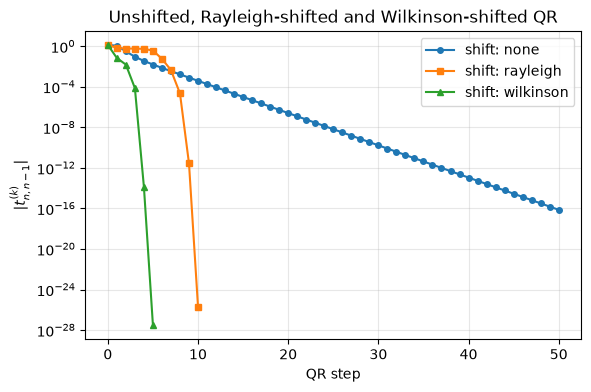

In [15]:
n = 10
S7 = np.random.default_rng(7).standard_normal((n, n))
T7, _ = tridiagonalize((S7 + S7.T) / 2)

histories = {}
for name in ("none", "rayleigh", "wilkinson"):
    Tk = T7.copy()
    hist = [abs(Tk[n - 1, n - 2])]
    for _ in range(60):
        if name == "wilkinson":
            mu = wilkinson_shift(Tk[n - 2, n - 2], Tk[n - 1, n - 2], Tk[n - 1, n - 1])
        elif name == "rayleigh":
            mu = Tk[n - 1, n - 1]
        else:
            mu = 0.0
        tridiag_qr_step(Tk, 0, n - 1, mu)
        hist.append(abs(Tk[n - 1, n - 2]))
        if hist[-1] <= u * (abs(Tk[n - 2, n - 2]) + abs(Tk[n - 1, n - 1])):
            break
    histories[name] = hist
    print(f"{name:10s}: {len(hist) - 1:2d} steps;  " + " ".join(f"{h:.1e}" for h in hist[:8]))

lam7 = np.linalg.eigvalsh(T7)
small = np.sort(np.abs(lam7))[:2]
print(f"ratio of the two smallest |eigenvalues| = {small[0] / small[1]:.3f}; "
      f"observed late ratio without shift = {histories['none'][-1] / histories['none'][-2]:.3f}")
ev7, steps7 = tridiag_eig(T7)
print(f"complete run with the Wilkinson shift and deflation: {steps7} steps")

fig, ax = plt.subplots()
for name, marker in (("none", "o"), ("rayleigh", "s"), ("wilkinson", "^")):
    ax.semilogy(histories[name], marker + "-", ms=4, label=f"shift: {name}")
ax.set_xlabel("QR step")
ax.set_ylabel(r"$|t_{n,n-1}^{(k)}|$")
ax.set_title("Unshifted, Rayleigh-shifted and Wilkinson-shifted QR")
ax.legend()
plt.show()

Without a shift the entry decreases linearly with the ratio of the two
eigenvalues of smallest modulus, because the last column performs inverse
iteration with shift $0$. The Rayleigh quotient shift stalls for a few steps
and then converges very fast; the Wilkinson shift deflates first. In the
complete run every eigenvalue needs only about two steps, because each new
active block starts from entries that the previous steps have already
reduced.

### The Rayleigh quotient shift can fail

For $\begin{bmatrix}0&1\\1&0\end{bmatrix}$ the Rayleigh quotient shift is $0$
and the iteration stagnates ([Example 10.3](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10-exa-rayleigh-failure)); the
Wilkinson shift is an eigenvalue and one step suffices.

In [16]:
P = np.array([[0.0, 1.0], [1.0, 0.0]])
try:
    tridiag_eig(P, shift="rayleigh", maxiter=100)
except RuntimeError as exc:
    print("Rayleigh quotient shift:", exc)
ev_p, steps_p = tridiag_eig(P, shift="wilkinson")
print(f"Wilkinson shift: eigenvalues {np.sort(ev_p)} after {steps_p} step")
assert steps_p == 1 and np.allclose(np.sort(ev_p), [-1.0, 1.0], rtol=0, atol=4 * u)

Rayleigh quotient shift: no convergence after 100 steps
Wilkinson shift: eigenvalues [-1.  1.] after 1 step


## 5. Real matrices with complex eigenvalues

### The real Schur form

`scipy.linalg.schur` (LAPACK `dgees`) returns the real Schur form
$A = ZTZ^T$: $T$ is quasi-upper-triangular, with a $2\times2$ diagonal block
for each complex conjugate pair.

In [17]:
n = 6
A = rng.standard_normal((n, n))
T, Zs = sla.schur(A)            # output="real" is the default
print(np.round(T, 3))
blocks = [j for j in range(n - 1) if abs(T[j + 1, j]) > 0]
for j in blocks:
    print(f"2x2 block at rows {j}:{j + 2}, eigenvalues {np.round(np.linalg.eigvals(T[j:j + 2, j:j + 2]), 4)}")
print("eigenvalues of A:", np.round(np.sort_complex(np.linalg.eigvals(A)), 4))
assert np.linalg.norm(A - Zs @ T @ Zs.T) < 10 * n * u * np.linalg.norm(A)

[[ 1.565 -1.479 -0.973  0.93  -1.724  0.932]
 [ 0.    -1.208 -1.815 -0.022  1.035  0.805]
 [ 0.     1.159 -1.208  1.613 -0.032 -0.032]
 [ 0.     0.     0.     0.216  0.098 -0.319]
 [ 0.     0.     0.     0.    -0.469  0.634]
 [ 0.     0.     0.     0.    -0.315 -0.469]]
2x2 block at rows 1:3, eigenvalues [-1.2079+1.4503j -1.2079-1.4503j]
2x2 block at rows 4:6, eigenvalues [-0.4691+0.4467j -0.4691-0.4467j]
eigenvalues of A: [-1.2079-1.4503j -1.2079+1.4503j -0.4691-0.4467j -0.4691+0.4467j
  0.2161+0.j      1.5651+0.j    ]


### A single real shift cannot isolate a complex eigenvalue

We apply the explicit Rayleigh quotient shift $\mu = h_{nn}$ to a real
$4\times4$ Hessenberg matrix whose eigenvalues are two complex conjugate pairs,
$2e^{\pm1.2i}$ and $0.9e^{\pm0.4i}$. By [Proposition 10.3](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10-prop-real-shift) all
iterates stay real, so no eigenvalue can be isolated in the bottom $1\times1$
position.

In [18]:
def rotation_block(r, phi):
    """Real 2x2 block with eigenvalues r exp(+-i phi)."""
    return r * np.array([[np.cos(phi), -np.sin(phi)], [np.sin(phi), np.cos(phi)]])


A = sla.block_diag(rotation_block(2.0, 1.2), rotation_block(0.9, 0.4))
W, _ = np.linalg.qr(np.random.default_rng(1).standard_normal((4, 4)))   # a random orthogonal similarity
H, _ = hessenberg_householder(W @ A @ W.T, calc_q=False)
last = []
for k in range(60):
    H = hessenberg_qr_step(H, mu=H[-1, -1])      # real Rayleigh quotient shift
    last.append(abs(H[-1, -2]))
print("|h_{n,n-1}| at steps 10, 20, ..., 60:", " ".join(f"{x:.3f}" for x in last[9::10]))
print(f"|h_(n-1,n-2)| after 60 steps: {abs(H[-2, -3]):.1e}")
print("eigenvalues of the trailing 2x2 block:", np.round(np.linalg.eigvals(H[-2:, -2:]), 6))
assert min(last) > 0.1 and abs(H[-2, -3]) < 1e-10

|h_{n,n-1}| at steps 10, 20, ..., 60: 0.350 0.350 0.350 0.350 0.350 0.350
|h_(n-1,n-2)| after 60 steps: 1.5e-44
eigenvalues of the trailing 2x2 block: [0.828955+0.350477j 0.828955-0.350477j]


The last subdiagonal entry does not become small. What does converge is the
entry *above* the trailing $2\times2$ block: the pair is isolated as a block,
which is the most that real arithmetic can give, and its eigenvalues are the
complex pair $0.9e^{\pm0.4i}\approx0.829\pm0.350i$.

### The Francis double-shift QR algorithm

The implementation below follows [Algorithm 10.4](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10-alg-francis). Transformations
are applied to the full rows and columns of $H$ and accumulated in $Z$, so that
the result is a real Schur form $A = ZTZ^T$. When a $2\times2$ block with
*real* eigenvalues deflates, we split it with one rotation whose first column
is an eigenvector, so that only blocks with complex eigenvalues remain. After
ten steps without deflation an ad hoc *exceptional* shift is used.

In [19]:
def francis_step(H, lo, hi, Z, shifts=None):
    """Implicit double-shift step on the active block H[lo:hi+1, lo:hi+1] (hi - lo >= 2)."""
    if shifts is None:        # s = trace, t = determinant of the trailing 2x2 block
        s = H[hi - 1, hi - 1] + H[hi, hi]
        t = H[hi - 1, hi - 1] * H[hi, hi] - H[hi - 1, hi] * H[hi, hi - 1]
    else:
        s, t = shifts
    x = H[lo, lo] ** 2 + H[lo, lo + 1] * H[lo + 1, lo] - s * H[lo, lo] + t   # (ch10-eq-francis-column)
    y = H[lo + 1, lo] * (H[lo, lo] + H[lo + 1, lo + 1] - s)
    z = H[lo + 1, lo] * H[lo + 2, lo + 1]
    for k in range(lo, hi - 1):
        v, beta = house(np.array([x, y, z]))
        q = max(lo, k - 1)
        H[k:k + 3, q:] -= beta * np.outer(v, v @ H[k:k + 3, q:])        # all columns to the right
        r = min(k + 4, hi + 1)
        H[:r, k:k + 3] -= beta * np.outer(H[:r, k:k + 3] @ v, v)        # all rows above
        Z[:, k:k + 3] -= beta * np.outer(Z[:, k:k + 3] @ v, v)
        if k > lo:
            H[k + 1:k + 3, k - 1] = 0.0
        x, y = H[k + 1, k], H[k + 2, k]
        if k < hi - 2:
            z = H[k + 3, k]
    v, beta = house(np.array([x, y]))
    k = hi - 1
    H[k:k + 2, k - 1:] -= beta * np.outer(v, v @ H[k:k + 2, k - 1:])
    H[:hi + 1, k:k + 2] -= beta * np.outer(H[:hi + 1, k:k + 2] @ v, v)
    Z[:, k:k + 2] -= beta * np.outer(Z[:, k:k + 2] @ v, v)
    H[k + 1, k - 1] = 0.0


def split_real_block(H, Z, i):
    """If H[i:i+2, i:i+2] has real eigenvalues, rotate it to upper triangular form."""
    a, b, c, d = H[i, i], H[i, i + 1], H[i + 1, i], H[i + 1, i + 1]
    disc = ((a - d) / 2) ** 2 + b * c
    if disc < 0:
        return False
    lam = (a + d) / 2 + np.copysign(np.sqrt(disc), (a + d) / 2)
    x1, x2 = np.array([b, lam - a]), np.array([lam - d, c])      # two formulas for an eigenvector
    x = x1 if np.linalg.norm(x1) >= np.linalg.norm(x2) else x2
    cs, sn = x / np.linalg.norm(x)
    G = np.array([[cs, -sn], [sn, cs]])                          # first column is the eigenvector
    H[i:i + 2, :] = G.T @ H[i:i + 2, :]
    H[:, i:i + 2] = H[:, i:i + 2] @ G
    Z[:, i:i + 2] = Z[:, i:i + 2] @ G
    H[i + 1, i] = 0.0
    return True


def francis_schur(A, exceptional=True, maxiter=None):
    """Real Schur form A = Z T Z^T by Hessenberg reduction and Francis double-shift QR.

    Returns T, Z and the number of double-shift steps."""
    H, Z = hessenberg_householder(A)
    n = H.shape[0]
    maxiter = maxiter or 30 * n
    hi, steps, since = n - 1, 0, 0
    while hi > 0:
        for i in range(hi):
            if abs(H[i + 1, i]) <= u * (abs(H[i, i]) + abs(H[i + 1, i + 1])):
                H[i + 1, i] = 0.0
        if H[hi, hi - 1] == 0.0:                   # 1x1 block: a real eigenvalue
            hi, since = hi - 1, 0
            continue
        if hi == 1 or H[hi - 1, hi - 2] == 0.0:    # 2x2 block
            split_real_block(H, Z, hi - 1)
            hi, since = hi - 2, 0
            continue
        lo = hi - 1
        while lo > 0 and H[lo, lo - 1] != 0.0:
            lo -= 1
        if steps >= maxiter:
            raise RuntimeError(f"no convergence after {maxiter} double-shift steps")
        shifts = None
        if exceptional and since > 0 and since % 10 == 0:   # ad hoc exceptional shift
            w = abs(H[hi, hi - 1]) + abs(H[hi - 1, hi - 2])
            a = H[hi, hi] + 0.75 * w
            shifts = (2 * a, a * a + 0.4375 * w * w)
        francis_step(H, lo, hi, Z, shifts)
        steps += 1
        since += 1
    return H, Z, steps


def schur_eigenvalues(T):
    """Eigenvalues of a quasi-triangular T (1x1 and 2x2 diagonal blocks)."""
    lam, j, n = [], 0, T.shape[0]
    while j < n:
        if j < n - 1 and T[j + 1, j] != 0.0:
            lam.extend(np.linalg.eigvals(T[j:j + 2, j:j + 2]))
            j += 2
        else:
            lam.append(T[j, j])
            j += 1
    return np.array(lam, dtype=complex)

**Verification.** The algorithm is backward stable, so $\|A - ZTZ^T\|/\|A\|$
and $\|Z^TZ - I\|$ should be a modest multiple of $nu$. For the eigenvalues,
first-order perturbation theory ([Chapter 9](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09)) says that a
backward error $E$ moves a simple eigenvalue $\lambda$ by at most about
$\kappa(\lambda)\|E\|_2$, where $\kappa(\lambda) = 1/|y^*x|$ for unit left and
right eigenvectors $y$, $x$. We compare with `numpy.linalg.eigvals` and use
the sum of two such bounds as tolerance.

In [20]:
n = 80
A = rng.standard_normal((n, n))
T, Z, steps = francis_schur(A)
normA = np.linalg.norm(A, 2)
res = np.linalg.norm(A - Z @ T @ Z.T, 2) / normA
orth = np.linalg.norm(Z.T @ Z - np.eye(n), 2)
quasi = all(T[j + 1, j] == 0 or (j + 2 >= n or T[j + 2, j + 1] == 0) for j in range(n - 1))
print(f"{steps} double-shift steps ({steps / n:.2f} per eigenvalue)")
print(f"||A - Z T Z^T||_2 / ||A||_2 = {res:.1e},  ||Z^T Z - I||_2 = {orth:.1e}")
print(f"T quasi-triangular: {quasi and np.abs(np.tril(T, -2)).max() == 0}")
assert res < 10 * n * u and orth < 10 * n * u and quasi

lam_ours = schur_eigenvalues(T)
w, vl, vr = sla.eig(A, left=True, right=True)
kappa = 1 / np.abs(np.sum(vl.conj() * vr, axis=0))      # columns are unit vectors
rows, cols = linear_sum_assignment(np.abs(w[:, None] - lam_ours[None, :]))
errs = np.abs(w[rows] - lam_ours[cols])
print(f"max eigenvalue difference = {errs.max():.1e}; max kappa(lambda) = {kappa.max():.1f}")
assert np.all(errs <= 2 * 10 * n * u * normA * kappa[rows])
print(f"complex pairs found: {int(np.sum(np.abs(np.diag(T, -1)) > 0))}; "
      f"nonreal eigenvalues / 2 from eigvals: {int(np.sum(np.abs(w.imag) > 0)) // 2}")

166 double-shift steps (2.08 per eigenvalue)
||A - Z T Z^T||_2 / ||A||_2 = 9.2e-15,  ||Z^T Z - I||_2 = 9.9e-15
T quasi-triangular: True
max eigenvalue difference = 7.3e-14; max kappa(lambda) = 36.9
complex pairs found: 36; nonreal eigenvalues / 2 from eigvals: 36


**The cyclic permutation.** For the matrix of [Example 10.4](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10-exa-cyclic), one
Francis step returns the same matrix up to signs, and without an exceptional
shift the iteration never deflates.

In [21]:
C = np.array([[0.0, 0.0, 1.0], [1.0, 0.0, 0.0], [0.0, 1.0, 0.0]])
H = C.copy()
francis_step(H, 0, 2, np.eye(3))
print("after one Francis step:\n", np.round(H, 14))
assert np.allclose(np.abs(H), C, atol=10 * u)
try:
    francis_schur(C, exceptional=False, maxiter=200)
except RuntimeError as exc:
    print("without exceptional shifts:", exc)
T_c, Z_c, steps_c = francis_schur(C)
print(f"with exceptional shifts: {steps_c} steps, eigenvalues "
      f"{np.round(np.sort_complex(schur_eigenvalues(T_c)), 12)}")

after one Francis step:
 [[ 0.  0.  1.]
 [-1.  0.  0.]
 [ 0. -1.  0.]]
without exceptional shifts: no convergence after 200 double-shift steps
with exceptional shifts: 15 steps, eigenvalues [-0.5-0.8660254j -0.5+0.8660254j  1. +0.j       ]


## 6. How many QR steps per eigenvalue?

The $\mathcal{O}(n^3)$ operation count of the QR algorithm rests on the
observation that only a few steps are needed per eigenvalue
([Section 10.8](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10-sec-cost)). We count steps for random symmetric matrices
(Wilkinson shift) and random nonsymmetric matrices (Francis double shift) of
several orders. The generator is seeded separately (seed 10) so that the
counts quoted in the notes can be reproduced.

In [22]:
gen = np.random.default_rng(10)
print("    n   symmetric: steps  per eigenvalue  err/u  |  Francis: steps  per eigenvalue")
for n in (25, 50, 100, 200):
    S = gen.standard_normal((n, n))
    S = (S + S.T) / 2
    T, _ = tridiagonalize(S)
    ev, steps_s = tridiag_eig(T)
    err = np.abs(np.sort(ev) - np.linalg.eigvalsh(S)).max() / np.linalg.norm(S, 2)
    B = gen.standard_normal((n, n))
    _, _, steps_f = francis_schur(B)
    print(f"{n:5d}   {steps_s:16d}  {steps_s / n:14.2f}  {err / u:5.0f}  |  "
          f"{steps_f:14d}  {steps_f / n:14.2f}")
    assert err < 10 * n * u

    n   symmetric: steps  per eigenvalue  err/u  |  Francis: steps  per eigenvalue
   25                 55            2.20     21  |              43            1.72
   50                109            2.18     26  |              97            1.94


  100                215            2.15     56  |             194            1.94


  200                407            2.04     50  |             357            1.78


**Interpretation.** In our implementation about two steps are needed per
eigenvalue, for both algorithms and for all these orders, where a Francis
step, which applies two shifts at once, is counted as one step. This is the
empirical fact behind the $\mathcal{O}(n^3)$ total: the number of steps grows
like $n$, not like $n^2$, and each costs $\mathcal{O}(n^2)$ flops. These
counts are observations for our test matrices, our deflation criterion and our
implementation; LAPACK's codes use more refined strategies and report
different counts.

## 7. Singular values: not from $A^TA$

### The Läuchli matrix

In [23]:
eps_l = 1e-8
L3 = np.array([[1.0, 1.0], [eps_l, 0.0], [0.0, eps_l]])
G = L3.T @ L3
print("computed A^T A =\n", G, "\n1 + eps^2 == 1 in floating point:", G[0, 0] == 1.0)
lam_G = np.linalg.eigvalsh(G)
sig_eig = np.sqrt(np.abs(lam_G))[::-1]
sig_svd = np.linalg.svd(L3, compute_uv=False)
print(f"sigma_2 from eig(A^T A): {sig_eig[1]:.3e};  from svd: {sig_svd[1]:.15e};  exact: {eps_l:.1e}")
assert G[0, 0] == 1.0 and sig_eig[1] == 0.0
assert abs(sig_svd[1] - eps_l) / eps_l < 10 * u

computed A^T A =
 [[1. 1.]
 [1. 1.]] 
1 + eps^2 == 1 in floating point: True
sigma_2 from eig(A^T A): 0.000e+00;  from svd: 9.999999999999999e-09;  exact: 1.0e-08


### Graded singular values

We build $A = U\Sigma V^T$ with prescribed singular values from $1$ down to
$10^{-12}$ and compare the absolute errors of the two methods, scaled by
$\sigma_1 = 1$. The estimate of [Section 10.10](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10-sec-svd) predicts errors of
order $u$ for a backward stable SVD and of order $u\sigma_1/\sigma_i$ for the
route through $A^TA$. (The errors of the SVD are measured against the
prescribed $\sigma_i$; forming $A$ itself already perturbs them by about $u$.)

negative computed eigenvalues of A^T A: 2


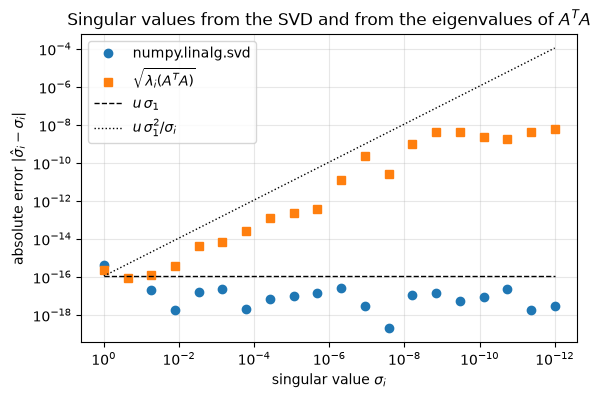

In [24]:
m, n = 30, 20
Uo, _ = np.linalg.qr(rng.standard_normal((m, n)))
Vo, _ = np.linalg.qr(rng.standard_normal((n, n)))
sigma = np.logspace(0, -12, n)
A = (Uo * sigma) @ Vo.T
s_svd = np.linalg.svd(A, compute_uv=False)
lam_ata = np.linalg.eigvalsh(A.T @ A)[::-1]
s_eig = np.sqrt(np.abs(lam_ata))
print(f"negative computed eigenvalues of A^T A: {int(np.sum(lam_ata < 0))}")

fig, ax = plt.subplots()
ax.loglog(sigma, np.abs(s_svd - sigma), "o", label="numpy.linalg.svd")
ax.loglog(sigma, np.abs(s_eig - sigma), "s", label=r"$\sqrt{\lambda_i(A^TA)}$")
ax.loglog(sigma, u * np.ones(n), "k--", lw=1, label=r"$u\,\sigma_1$")
ax.loglog(sigma, u / sigma, "k:", lw=1, label=r"$u\,\sigma_1^2/\sigma_i$")
ax.invert_xaxis()
ax.set_xlabel(r"singular value $\sigma_i$")
ax.set_ylabel(r"absolute error $|\hat\sigma_i - \sigma_i|$")
ax.set_title("Singular values from the SVD and from the eigenvalues of $A^TA$")
ax.legend()
plt.show()
assert np.all(np.abs(s_svd - sigma) < 10 * n * u)          # backward stable: absolute error O(n u sigma_1)
assert np.abs(s_eig - sigma)[-1] > 1e3 * sigma[-1]         # no correct digit in the smallest one

The SVD errors stay near $u$ for all singular values, which means that the
tiny singular values have large *relative* errors: $10^{-16}$ absolute error
in $10^{-12}$ is a relative error of $10^{-4}$. That is the best a backward
stable algorithm can promise for a general dense matrix, since the data
themselves carry errors of this size. The errors of the $A^TA$ route grow like
$u\sigma_1^2/\sigma_i$ until they level off near $\sqrt u\approx10^{-8}$: the
computed eigenvalues of $A^TA$ near zero are rounding noise of size about $u$,
and their square roots are of size about $\sqrt u$. From
$\sigma_i\lesssim\sqrt u$ on, the error exceeds the singular value itself.

### Golub--Kahan bidiagonalization

[Algorithm 10.5](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10-alg-bidiag) alternates reflectors from the left (zeroing a
column below the diagonal) and from the right (zeroing a row to the right of
the superdiagonal). The singular values must be preserved.

In [25]:
def bidiagonalize(A):
    """Golub-Kahan bidiagonalization U^T A V = B for m >= n; returns the n x n upper bidiagonal B."""
    B = np.array(A, dtype=float)
    m, n = B.shape
    for k in range(n):
        v, beta = house(B[k:, k])
        B[k:, k:] -= beta * np.outer(v, v @ B[k:, k:])
        B[k + 1:, k] = 0.0
        if k < n - 2:
            v, beta = house(B[k, k + 1:])
            B[k:, k + 1:] -= beta * np.outer(B[k:, k + 1:] @ v, v)
            B[k, k + 2:] = 0.0
    return B[:n, :n]


m, n = 40, 12
A = rng.standard_normal((m, n))
Bd = bidiagonalize(A)
off = Bd - np.diag(np.diag(Bd)) - np.diag(np.diag(Bd, 1), 1)
d_sv = np.abs(np.linalg.svd(Bd, compute_uv=False) - np.linalg.svd(A, compute_uv=False)).max()
print(f"entries outside the bidiagonal: {np.abs(off).max()};  max singular value difference = {d_sv:.1e}")
assert np.abs(off).max() == 0 and d_sv < 10 * m * u * np.linalg.norm(A, 2)

entries outside the bidiagonal: 0.0;  max singular value difference = 2.7e-15


The augmented matrix of the bidiagonal $B$, reordered as
$v_1,u_1,v_2,u_2,\dots$, is tridiagonal with zero diagonal
([Exercise 10.12](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10-ex-augmented)). Our symmetric tridiagonal QR algorithm applied to
it returns $\pm\sigma_i$, a small illustration of how closely the SVD and the
symmetric eigenvalue algorithms are related (in practice one works on $B$
directly, as described in the notes).

In [26]:
d, f = np.diag(Bd), np.diag(Bd, 1)
off_diag = np.empty(2 * n - 1)
off_diag[0::2], off_diag[1::2] = d, f
T_gk = np.diag(off_diag, 1) + np.diag(off_diag, -1)
ev_gk, steps_gk = tridiag_eig(T_gk)
sv = np.linalg.svd(A, compute_uv=False)
diff = np.abs(np.sort(ev_gk) - np.sort(np.concatenate([sv, -sv]))).max()
print(f"{steps_gk} QR steps; max | eig - (+-sigma) | = {diff:.1e}")
assert diff < 10 * m * u * sv[0]

54 QR steps; max | eig - (+-sigma) | = 1.6e-14


Finally, the augmented matrix of a rectangular $A$ is singular, so the claim
$\kappa_2(C) = \kappa_2(A)$ holds only for square nonsingular $A$.

In [27]:
for (m, n) in ((6, 6), (6, 4)):
    A = rng.standard_normal((m, n))
    C = np.block([[np.zeros((n, n)), A.T], [A, np.zeros((m, m))]])
    evC = np.linalg.eigvalsh(C)
    print(f"m = {m}, n = {n}: kappa(A) = {np.linalg.cond(A):.3f}, "
          f"smallest |eigenvalue of C| = {np.abs(evC).min():.1e}, kappa(C) = {np.linalg.cond(C):.3e}")

m = 6, n = 6: kappa(A) = 26.331, smallest |eigenvalue of C| = 1.7e-01, kappa(C) = 2.633e+01
m = 6, n = 4: kappa(A) = 2.938, smallest |eigenvalue of C| = 4.5e-16, kappa(C) = 1.065e+17


## Common mistakes

- Iterating QR steps on a full matrix. Without the Hessenberg reduction every
  step costs $\mathcal{O}(n^3)$ flops and the whole computation
  $\mathcal{O}(n^4)$.
- Forgetting deflation, or deflating with an absolute tolerance such as
  $10^{-12}$. Without deflation the shift is computed from an already
  converged block and the step counts are meaningless.
- Using a single real shift for a real matrix with complex eigenvalues, and
  expecting the last subdiagonal entry to converge.
- Updating only the active block in a Schur-form computation. The off-diagonal
  blocks and the accumulated $Z$ must be updated too, or $A\neq ZTZ^T$.
- Claiming that the Wilkinson shift guarantees cubic convergence. It
  guarantees convergence (symmetric case); cubic is the generic rate.
- Computing singular values as `np.sqrt(np.linalg.eigvals(A.T @ A))`.
- Comparing eigenvalues of nonsymmetric matrices with a tolerance of a few
  $u$: the forward error also involves the eigenvalue condition number.

## Your turn

1. Replace the deflation test by the absolute test $|t_{j+1,j}|\le10^{-12}$
   and repeat Section 6 for matrices scaled by $10^{-6}$ and $10^{6}$. What
   goes wrong?
2. Modify `tridiag_eig` to use the Rayleigh quotient shift and count the steps
   for the matrices of Section 6. Does it ever fail?
3. Apply `francis_schur` to the companion matrix of $z^5 - 4z + 2$ and compare
   its eigenvalues with `numpy.roots`.
4. Solve [Exercise 10.13](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10-ex-path-laplacian): the Laplacian of a path graph has known
   eigenvalues, which makes it a good test of `tridiag_eig`.
5. Measure the relative errors of $\sigma_2$ for the Läuchli matrix with
   $\epsilon = 10^{-4}, 10^{-6}, 10^{-8}$ ([Exercise 10.11](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10-ex-lauchli)).

## Key takeaways

- The dense eigenvalue problem is solved in two phases: an $\mathcal{O}(n^3)$
  Householder reduction to Hessenberg (tridiagonal) form, and the QR
  iteration, whose steps then cost $\mathcal{O}(n^2)$ ($\mathcal{O}(n)$).
- The unshifted QR algorithm is simultaneous iteration,
  $A^k = \underline Q^{(k)}\underline R^{(k)}$, with linear convergence at the
  ratios $|\lambda_{j+1}/\lambda_j|$.
- Shifts, deflation and implicit bulge chasing make it fast: about two steps
  per eigenvalue in our experiments. The Wilkinson shift is globally convergent
  for symmetric tridiagonal matrices; the Rayleigh quotient shift can fail.
- Real matrices with complex eigenvalues need the Francis double shift, and
  converge to real Schur form with $2\times2$ blocks.
- Singular values are computed by bidiagonalization and an implicit QR (or
  divide and conquer) iteration, never from $A^TA$.

## Further reading

Trefethen and Bau (1997), Lectures 25--31; Golub and Van Loan (2013), Sections
7.4--7.5 and 8.3--8.6; Demmel (1997), Chapters 4 and 5;
Watkins (2007). The LAPACK routines are documented in
Anderson et al. (1999).